## Evaluation pipeline for the microlane experiment

In [1]:
# First consider all the variables
# The input image gets resized to a particular level
# Then create a pipeline to feed data into the model
# AFter this process is completed, then process the data
# Then after the processing is done find a way to take output from the model
# Then, convert the output to relevant format, and store it for future use
# Apply relevant computations

In [2]:
# Imports of the Core Packages
import json, sys, time
from pathlib import Path
from datetime import datetime

import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import yaml
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import random


In [3]:
# Import custom libraries located at different folder location + configs
from microlane.utils.metrics import *
from microlane.datasets.tusimple import TuSimple
from microlane.models.lanenet2.model import LaneNet2
from microlane.schema.output import LaneNet2Output
from microlane.utils.load_image import load_image_from_sample

In [4]:
# First Load the Configuation file
with open("configs/config.yaml", "r") as file:
    config = yaml.safe_load(file)

### Pre Processing Part

In [5]:
# First initialise the dataset
# Then load the dataset
dataset = TuSimple(
        folder_path=config['data']['datasets']['tusimple']['path'],
        annotation_file_path=config['data']['datasets']['tusimple']['annotation_file']
    )

data = dataset.load(number=10)

In [6]:
# Print some basic information of our data

print(f"Total items: {len(data)}\n")

random_image_index = random.randint(0, len(data)-1)

item = data[random_image_index]
print(f"Image Path   : {item.image_path}")
print(f"Lanes        : {item.actual_lanes}")
print(type(item.image))

Total items: 10

Image Path   : /home/suyog/assets/datasets/TuSimple/TUSimple/test_set/clips/0530/1492626397007603377_0/20.jpg
Lanes        : [LaneLine(x_coordinates=[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 634, 625, 615, 606, 596, 587, 577, 568, 559, 549, 540, 530, 521, 511, 502, 493, 483, 474, 464, 455, 445, 436, 426, 417, 408, 398, 389, 379, 370, 360, 351, 342, 332, 323, 313, 304, 294, 285, 276, 266, 257, 247, 238, 228, -2], y_coordinates=[160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710]), LaneLine(x_coordinates=[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 702, 715, 727, 740, 752, 765, 777, 790, 802, 815, 827, 840, 852, 864, 877, 889, 902, 914, 927, 939, 952, 964, 977, 989, 1002, 1014, 1027, 1039, 1052, 1064, 1076, 1089, 1101, 1114, 1126, 1139, 1151, 1164,

### Processing Part where we do the Inference

In [7]:
# So, basically now we will import the model
# model = LaneNet2() type and what we will do is, run 
# Run model.inference(formatted_dataset)

model = LaneNet2(
    
    container_folder=config['models']['lanenet2']['container_folder'],
    
    image_name=config['models']['lanenet2']['image_name']
)

Initializing container on port  8000
/home/suyog/desktop/projects/microlane/microlane/models/lanenet2/lanenet2
Image 'lanenet2_image:latest' already exists, skipping build.
Container already running: c0c007b59cca


In [8]:

loaded_image = load_image_from_sample(item)

In [9]:
response = model.predict(loaded_image)

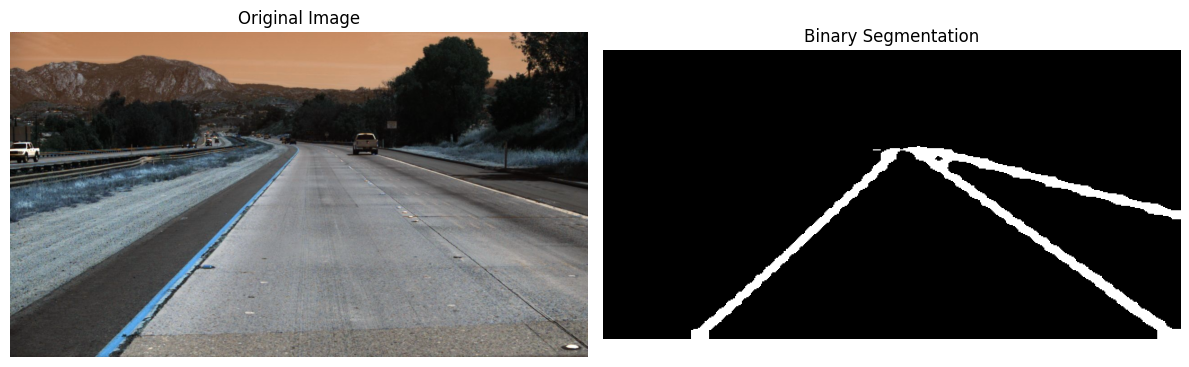

In [10]:
prediction = LaneNet2Output( **response.json() )

sample = prediction.sample
binary_seg = prediction.binary_segmentation

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(sample['image'])
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(binary_seg, cmap='gray')
axes[1].set_title("Binary Segmentation")
axes[1].axis('off')

plt.tight_layout()
plt.show()